In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 911.6/911.6 kB 14.9 MB/s eta 0:00:00


In [2]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [11]:
class YOLODetector:
    def __init__(self, model_path):
        self.model = YOLO(model_path)

    def detect(self, image_path):
        results = self.model(image_path)
        return self._process_results(results[0])

    def _process_results(self, result):
        detections = []
        for box in result.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            confidence = float(box.conf[0])
            cls = int(box.cls[0])
            label = result.names[cls]

            detections.append({
                "label": label,
                "confidence": confidence,
                "bbox": [x1, y1, x2, y2]
            })

        return {"detections": detections}

    def visualize_results(self, image_path, results):
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        for detection in results['detections']:
            x1, y1, x2, y2 = detection['bbox']
            label = f"{detection['label']} {detection['confidence']:.2f}"

            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(image, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

        plt.figure(figsize=(10, 10))
        plt.imshow(image)
        plt.axis('off')
        plt.show()


Running inference with model: yolov8n.pt

image 1/1 /content/xian.jpg: 416x640 3 persons, 2 bicycles, 250.2ms
Speed: 5.3ms preprocess, 250.2ms inference, 2.1ms postprocess per image at shape (1, 3, 416, 640)


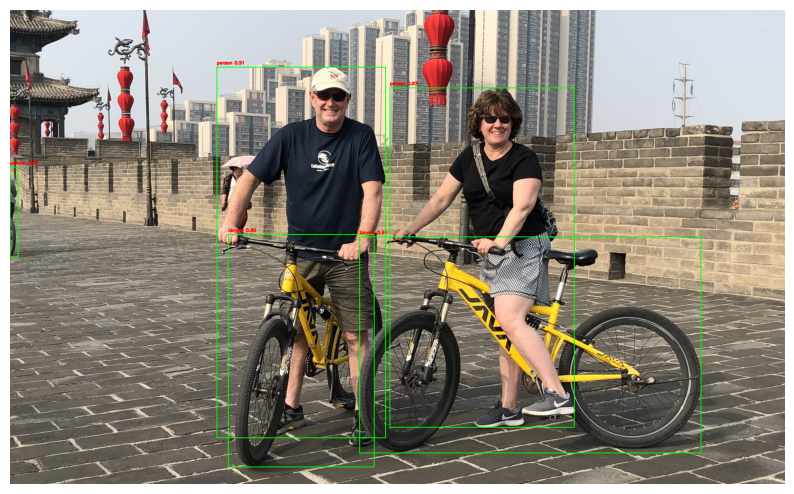

{'yolov8n.pt': {'detections': [{'label': 'bicycle', 'confidence': 0.9097943902015686, 'bbox': [1200, 781, 2372, 1522]}, {'label': 'person', 'confidence': 0.9069114327430725, 'bbox': [710, 199, 1289, 1470]}, {'label': 'person', 'confidence': 0.871190071105957, 'bbox': [1304, 270, 1937, 1434]}, {'label': 'bicycle', 'confidence': 0.8006154298782349, 'bbox': [749, 773, 1250, 1570]}, {'label': 'person', 'confidence': 0.3888765871524811, 'bbox': [0, 542, 27, 849]}]}}


In [14]:
if __name__ == "__main__":
    model_paths = ['yolov8n.pt']
    detectors = {model_path: YOLODetector(model_path) for model_path in model_paths}

    image_path = '/content/xian.jpg'

    results_dict = {}
    for model_name, detector in detectors.items():
        print(f"Running inference with model: {model_name}")
        results = detector.detect(image_path)
        results_dict[model_name] = results

        detector.visualize_results(image_path, results)

    print(results_dict)